# Goal 1：条件化真实 pilot、基线与独立审核

对应教师《作业1轨迹数据预处理》Notebook 的工作版。固定使用记录 0、1、2、246、256、306、352，从原始 JSON 重新运行获批的基础链，不改教师文件。源坐标基准仍为 **UNVERIFIED**；局部工作坐标是明确授权的分析假设，不是源 CRS 事实或坐标偏移校正。

默认 **Restart Kernel → Run All** 只执行确定性工具及审核，新增模型调用为 0。本文件是工作材料，正式 Experiment / Process Report 尚未定稿。

In [1]:
from pathlib import Path
import json, sys, html
from IPython.display import display, HTML, Image
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'AGENTS.md').is_file())
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from task1.workflow.io import DATA, CONFIG, EVIDENCE, read_json, digest, object_hash
from task1.workflow.tools import execute_tool
from task1.scripts.build_complete_figures import load_current
REVISION = EVIDENCE/'revisions/SC-LAB1-G1-COMPLETE-001'
current, manifest, saved_baseline = load_current()
policy = read_json(CONFIG)
record_ids = manifest['record_scope']
raw = read_json(DATA)
assert digest(DATA) == manifest['input_sha256'] == policy['raw_sha256']

def show_table(rows):
    if not rows:
        print('No rows')
        return
    columns = list(rows[0])
    def cell(value):
        return html.escape(json.dumps(value, ensure_ascii=False) if isinstance(value, (dict, list)) else str(value))
    header = ''.join('<th style="text-align:left;padding:6px">'+cell(c)+'</th>' for c in columns)
    body = ''.join('<tr>'+''.join('<td style="padding:6px;vertical-align:top">'+cell(row.get(c, ''))+'</td>' for c in columns)+'</tr>' for row in rows)
    display(HTML('<table><thead><tr>'+header+'</tr></thead><tbody>'+body+'</tbody></table>'))

print('Current run:', current['run_id'])
print('Processing CODE_SHA:', manifest['code_sha'])
print('Raw SHA256:', digest(DATA))
print('Fixed development record scope:', record_ids)
print('Default mode: RECOMPUTE; new model calls: 0')

Current run: g1-complete-pilot-03
Processing CODE_SHA: f229d9a4113bcc0dd763e1b410f1f5fb73903a62
Raw SHA256: c59be4c079d2ffd8ae0127c8a361c77ba277252abb2c7202efb9ee4e8e6084d3
Fixed development record scope: ['0', '1', '2', '246', '256', '306', '352']
Default mode: RECOMPUTE; new model calls: 0


## 数据范围与坐标语义

原始结构声明为 `(longitude, latitude)` 度与 Unix 秒。没有文件绑定的 datum / offset 说明，因此不指定源 EPSG、不叠底图、不声称绝对定位精度。固定局部 ENU 模型将原始角度映射为米制工作坐标；椭球形状和零高度是分析假设。原始值、原始索引、适配器版本及 raw→working 关系保留在可信参考链中。

In [2]:
from task1.workflow.pipeline import trusted_real_reference
from task1.workflow.evaluation import review_baseline
reference, contract, provenance = trusted_real_reference(raw, record_ids, policy)
assert contract['source_crs'] == 'UNVERIFIED'
print(json.dumps({k:contract[k] for k in ['contract_id','approval','source_crs','classification','units','adapter_version','analysis_model','limitations']}, ensure_ascii=False, indent=2))
show_table([{'record_id':r['record_id'], 'original_points':len(r['indices']), 'raw_record_sha256':r['raw_record_sha256']} for r in reference])

{
  "contract_id": "G1_CONDITIONAL_ENU_V1",
  "approval": "CONDITIONAL_ANALYSIS",
  "source_crs": "UNVERIFIED",
  "classification": "CURRENT_RUN_CONDITIONAL_ANALYSIS",
  "units": {
    "xy": "metre",
    "time": "second",
    "direction": "degrees"
  },
  "adapter_version": "conditional_ellipsoid_enu:v1",
  "analysis_model": {
    "name": "ellipsoid_surface_ECEF_to_local_ENU",
    "semi_major_m": 6378137.0,
    "inverse_flattening": 298.257223563,
    "assumed_height_m": 0.0,
    "origin_lon_degrees": 121.343555,
    "origin_lat_degrees": 31.3561015,
    "origin_basis": "midpoint of fixed pilot raw bounding box; chosen from extent, before processing",
    "domain_max_radius_m": 40000.0,
    "source_epsg": null,
    "datum_conversion": null,
    "coordinate_order": "longitude,latitude",
    "angular_unit": "degree"
  },
  "limitations": [
    "unknown source datum and offset history",
    "zero height is an analysis assumption, not measured elevation",
    "no absolute positioning, map 

record_id,original_points,raw_record_sha256
0,99,bd721b3d631cba7f30fd33f1ba938b9ac06e56eb5616a6e27743489650984b07
1,97,e6e73ef8c820154f78037c8fd7106ef843c079755a2e61dc385d36a033551615
2,99,ad048a0da65c3626892ae96f97a9016c14b1b81124eaa59abd1869b1625d53fa
246,108,aa370272c336e3b85ca414f93dbce191f390c9b5efd582b37b5fab463485ab95
256,99,7cc8872310d883690b11b6d7bfb40f115a996ffd6f944c124243a45e57538e90
306,111,01776fe816e2fe415025cf89f006cf5ebeaed0b854c00d96232fd55e4c9015fe
352,170,7e0d992c4a8471c00ca9192b455afd6c0a9a0ece5315c6344b73b59d969b8271


## 固定方法与参数

顺序为分段→独立过滤→方向去噪→DP。时间/距离分段使用严格 `>`，阈值等号不切；负时间差单独切分，右点进入新片段。过滤分别检查点数和片段累积长度。方向规则对当前输入片段计算一次：比较本点 outgoing edge 与前后 outgoing edge 的圆周差，两侧都严格超过阈值才标记，随后同时删除；端点及无法计算的窗口保留，并重算下游特征。DP 使用有限线段和原始索引区间。

参数沿用 starter 参考值，未开展参数搜索；95 m 教学例子未混入 400 m 距离阈值。

In [3]:
show_table([{'parameter':key, 'value':value} for key,value in contract['parameters'].items()])
print('Order:', contract['order'])
print('Direction schedule:', contract['method'])
print('Approval source:', contract['approval_source'])
print('Reference provenance:', json.dumps(provenance, ensure_ascii=False, indent=2))

parameter,value
dt,30
distance,400
min_points,5
min_length,65
direction,35
dp,5
time_reliable,True


Order: ['split', 'filter', 'denoise', 'simplify']
Direction schedule: single_pass_simultaneous_keep_undefined
Approval source: {'path': 'task1/evidence/goal1/revisions/SC-LAB1-G1-COMPLETE-001/USER_DECISIONS.json', 'sha256': '2b68e39573ab9256a353484842438a118445bb62ddbaca1c42fbd4eee9fe4f0e'}
Reference provenance: {
  "source_kind": "CURRENT_RUN_CONDITIONAL_ANALYSIS",
  "raw_sha256": "c59be4c079d2ffd8ae0127c8a361c77ba277252abb2c7202efb9ee4e8e6084d3",
  "raw_scope_sha256": "a98c638ce71bf2da36c9f27dfc7638731408250a27cfeb59e2ace6a576957f92",
  "reference_sha256": "27160aa567ff33ab560bdb27d722b3c74828d9c0ac894cdf445f8333b5a572dc",
  "record_scope": [
    "0",
    "1",
    "2",
    "246",
    "256",
    "306",
    "352"
  ],
  "parent_version": "RAW:c59be4c079d2ffd8ae0127c8a361c77ba277252abb2c7202efb9ee4e8e6084d3",
  "adapter_version": "conditional_ellipsoid_enu:v1",
  "contract_id": "G1_CONDITIONAL_ENU_V1",
  "contract_version": "BASELINE_CONTRACT_V2",
  "contract_sha256": "a817413dd8a7fa52f

## 从原始输入实际重算并独立审核

下面调用实际 baseline 工具。审核器接收候选之外的完整输入、预先固定合同及 provenance，不从候选 input 或候选容差取得答案；实际 clean/final 值、断点、过滤理由、方向决策、DP 区间和终态账本均进入核对。保存产物仅作为重算后的版本对照。

In [4]:
baseline = execute_tool('baseline', record_ids, policy)
assert baseline['status'] == 'VERIFIED', baseline.get('reason')
audit = review_baseline(baseline, reference, contract, provenance)
assert audit['status'] == 'VERIFIED' and not audit['unchecked_components'], audit
assert object_hash(baseline) == manifest['artifacts']['baseline']['output_sha256']
assert baseline['classification'] == 'CURRENT_RUN_CONDITIONAL_ANALYSIS'
assert digest(DATA) == manifest['input_sha256']
print('Fresh baseline:', baseline['status'], '| independent review:', audit['status'])
print('Checked:', audit['checked_components'])
print('Saved-current comparison: exact output hash match; new model calls: 0')

Fresh baseline: VERIFIED | independent review: VERIFIED
Checked: ['provenance', 'contract', 'segmentation', 'filtering', 'direction', 'actual_values', 'dp_intervals', 'point_accounting', 'summaries']
Saved-current comparison: exact output hash match; new model calls: 0


## 每条记录的逐阶段去向

“分段数”是片段数量，其余计数是点数。filtered、denoised、simplified、retained 是互斥终态；简化前参考点仅指经过过滤和方向去噪后进入 DP 的 clean 点。

In [5]:
stage_rows=[]
for row in baseline['records']:
    counts=row['stage_counts']
    clean_points=counts['input']-counts['filtered']-counts['denoised']
    stage_rows.append({'record':row['record_id'], 'input':counts['input'], 'segments':counts['segmented'], 'filtered':counts['filtered'], 'direction_deleted':counts['denoised'], 'DP_reference':clean_points, 'DP_omitted':counts['simplified'], 'retained':counts['retained'], 'not_processed':counts['not_processed']})
show_table(stage_rows)
print('Global stage counts:', baseline['stage_counts'])
print('Complete ledger points:', len(baseline['point_actions']))
assert len(baseline['point_actions']) == baseline['stage_counts']['input']
assert audit['accounting']['count_conserved']

record,input,segments,filtered,direction_deleted,DP_reference,DP_omitted,retained,not_processed
0,99,1,99,0,0,0,0,0
1,97,1,97,0,0,0,0,0
2,99,1,99,0,0,0,0,0
246,108,1,0,3,105,69,36,0
256,99,9,0,0,99,45,54,0
306,111,11,4,2,105,36,69,0
352,170,6,10,8,152,123,29,0


Global stage counts: {'input': 783, 'segmented': 30, 'filtered': 309, 'denoised': 13, 'simplified': 273, 'retained': 188, 'not_processed': 0}
Complete ledger points: 783


## DP 的分母、误差与适用边界

DP 点数节省为 `1 − N_final / N_clean`，不把上游过滤或去噪损失算成简化收益。每个 clean 点只对其原始索引区间对应的保留线段计算误差，不能匹配轨迹中其他恰好邻近的线段。误差阈值来自合同，数值余量为事前固定的 `64 × binary64 epsilon × max(1, 坐标尺度, tolerance)`。

In [6]:
metric_rows=[]
for row in baseline['records']:
    segments=row['processed_segments']
    n_clean=sum(len(s['denoise']['record']['indices']) for s in segments)
    n_final=sum(len(s['output']['indices']) for s in segments)
    errors=[s['independent_review']['metrics']['max_error']['value'] for s in segments if s['independent_review']['metrics']['max_error']['value'] is not None]
    metric_rows.append({'record':row['record_id'], 'clean_reference_points':n_clean, 'final_points':n_final, 'DP_saving':1-n_final/n_clean if n_clean else None, 'max_interval_error_m':max(errors) if errors else None, 'no_output_reason':row['terminal_status'] if not n_final else None})
show_table(metric_rows)
total_clean=sum(r['clean_reference_points'] for r in metric_rows)
total_final=sum(r['final_points'] for r in metric_rows)
print('Aggregate DP saving:', 1-total_final/total_clean if total_clean else None)
print('Quality status:', audit['quality_status'])

record,clean_reference_points,final_points,DP_saving,max_interval_error_m,no_output_reason
0,0,0,None,None,ALL_FILTERED
1,0,0,None,None,ALL_FILTERED
2,0,0,None,None,ALL_FILTERED
246,105,36,0.6571428571428571,4.768356861321128,None
256,99,54,0.4545454545454546,4.592745496123116,None
306,105,69,0.34285714285714286,4.938319812632411,None
352,152,29,0.8092105263157895,4.344985593528114,None


Aggregate DP saving: 0.5921908893709328
Quality status: PENDING_RESEARCH_REVIEW


## 本轮真实轨迹图与点终态分布

原始点只画散点；clean 与 final 的线段都来自实际处理片段，不跨断点、过滤片段或记录连接。各轨迹面板独立取轴范围，面板内 x/y 比例相同。图展示处理关系，不据此判断真实恢复或效果提升。

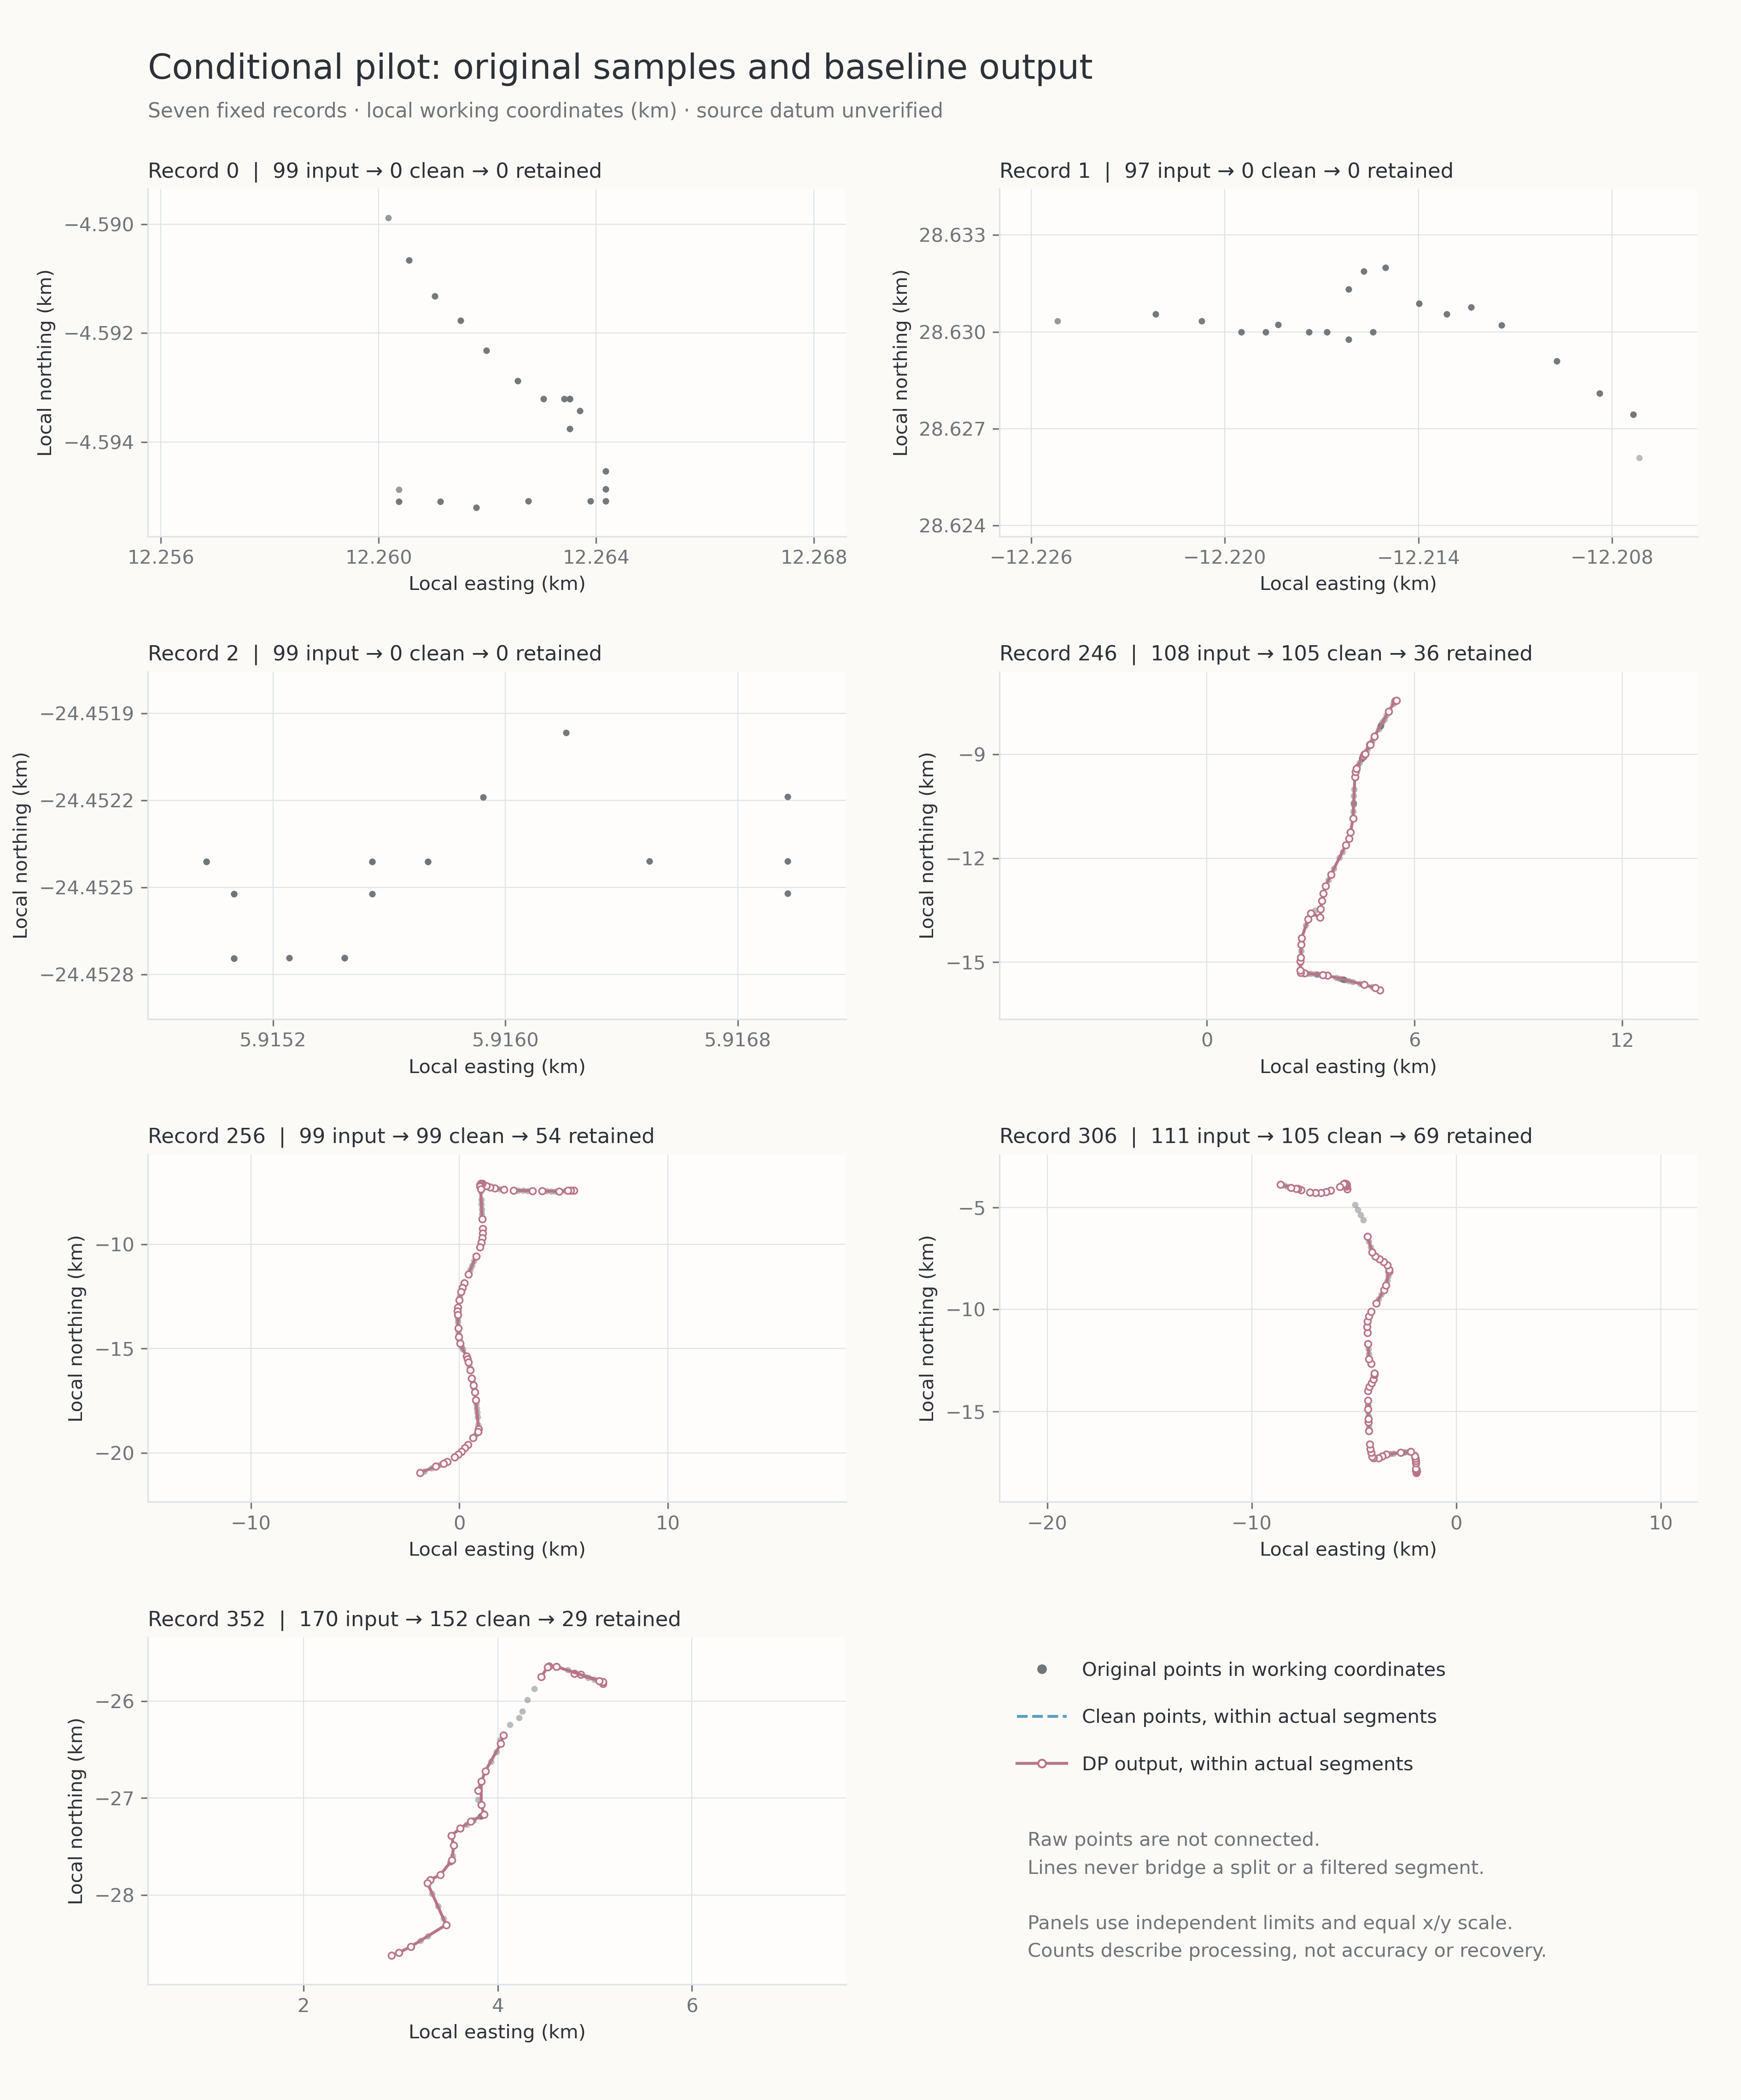

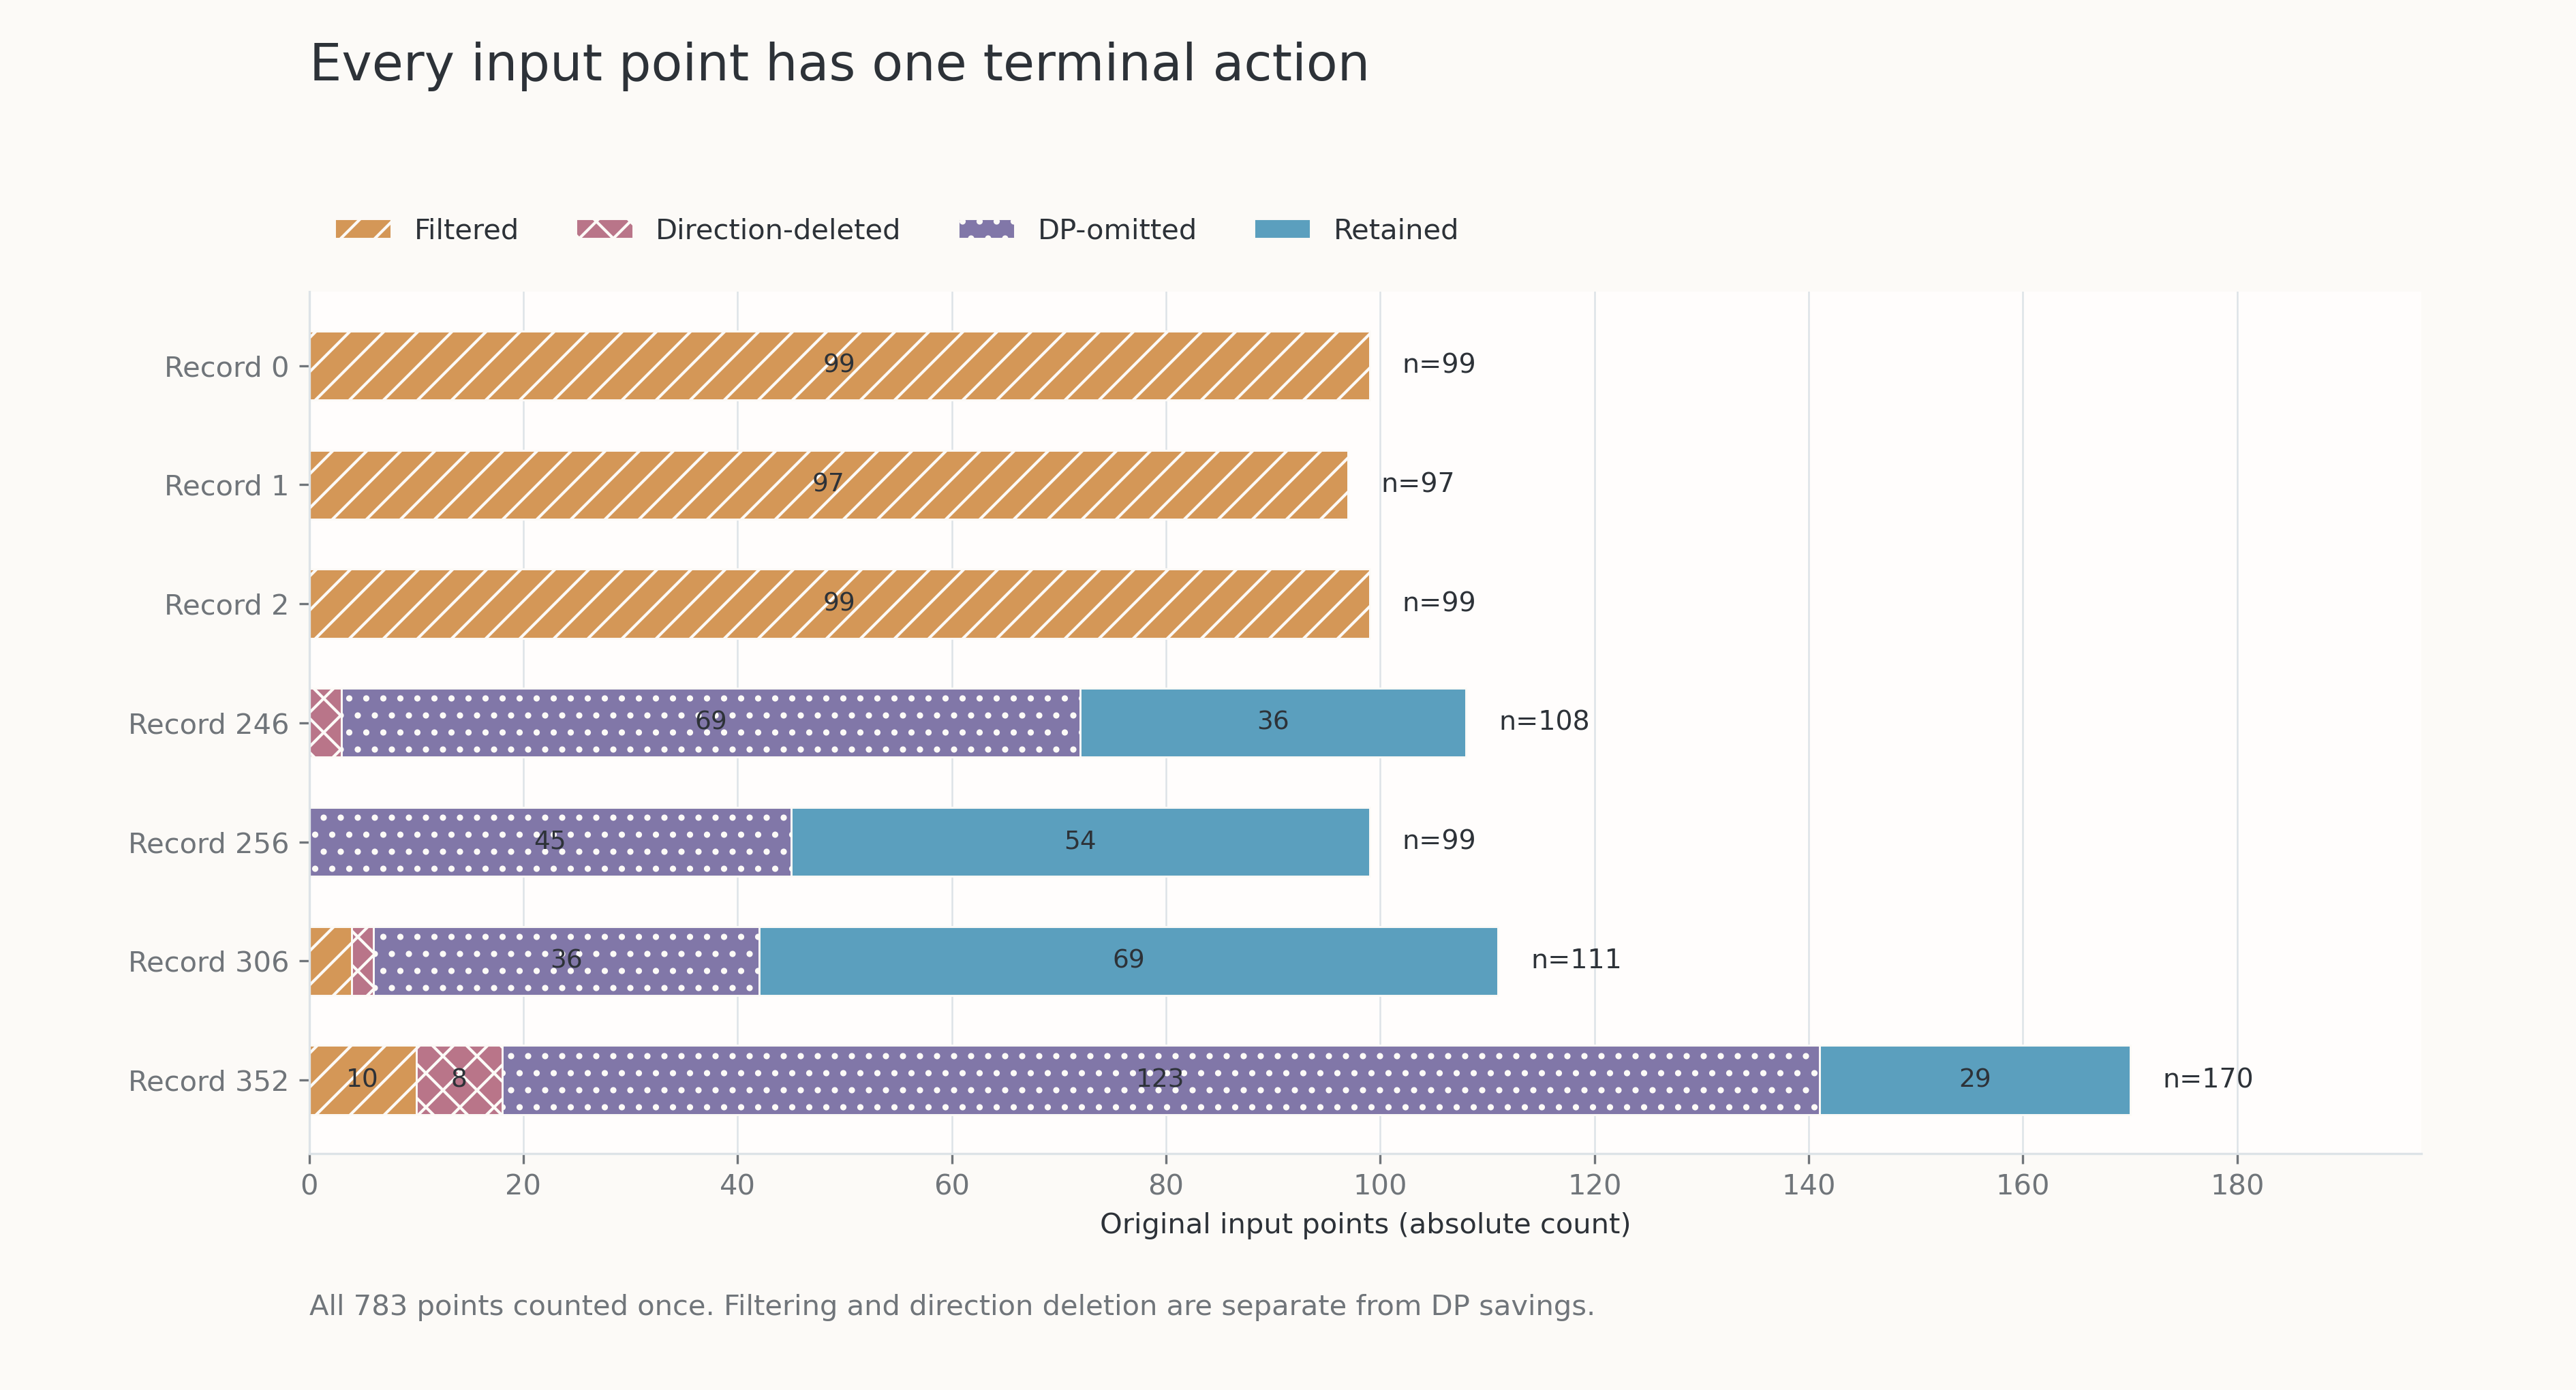

In [7]:
figures=REVISION/'figures'
figure_manifest=read_json(figures/'figure_manifest.json')
assert figure_manifest['run_id']==current['run_id']
assert figure_manifest['baseline']['sha256']==manifest['artifacts']['baseline']['sha256']
for name in ('conditional_pilot_trajectories','point_terminal_counts'):
    display(Image(filename=str(figures/(name+'.png')), width=1150))

## 解释限制

局部坐标模型的一致性核验不证明源 datum；应结合本轮 coordinate_sensitivity 产物查看近似误差及阈值影响。无独立真值标签，因此不报告误删率、检测准确率或真实恢复准确率；几何保真也不自动证明时间保真。七条记录属于开发 pilot，不能代表全量或最终留出。未运行 Goal 2 参数/顺序比较、未完成 Goal 3 正式报告和提交。

In [8]:
followup=REVISION/'runs'/current['run_id']/'coordinate_sensitivity.json'
if followup.exists():
    sensitivity=read_json(followup)
    print('Follow-up artifact:', followup.relative_to(ROOT))
    print('SHA256:', digest(followup))
    keys=['status','errors','source_crs','points_checked','within_record_pairs_checked','max_coordinate_crosscheck_error_m','max_model_geodesic_radius_m','max_pair_distance_relative_difference','max_pair_distance_absolute_difference_m','processing_threshold_checks','edge_400m_disagreements','segment_65m_disagreements','direction_35deg_disagreements','dp_5m_disagreements','source_datum_proven','interpretation']
    print(json.dumps({k:sensitivity.get(k) for k in keys},ensure_ascii=False,indent=2))
    if isinstance(sensitivity.get('dp_5m_checks'),list): show_table(sensitivity['dp_5m_checks'])
else:
    print('Coordinate-sensitivity follow-up: NOT_RUN; no result is inferred.')
print('Formal reports: working material only; GPT second review: PENDING; Submission: NOT_READY')

Follow-up artifact: task1/evidence/goal1/revisions/SC-LAB1-G1-COMPLETE-001/runs/g1-complete-pilot-03/coordinate_sensitivity.json
SHA256: 0ccffb15396c6ab1e57cc29fdb3e4ab9879104c73f95679dc1ac09d109d6de9f
{
  "status": "VERIFIED",
  "errors": [],
  "source_crs": "UNVERIFIED",
  "points_checked": 783,
  "within_record_pairs_checked": 45457,
  "max_coordinate_crosscheck_error_m": 3.637978807091713e-12,
  "max_model_geodesic_radius_m": 31131.317939847395,
  "max_pair_distance_relative_difference": 1.1826369614622246e-05,
  "max_pair_distance_absolute_difference_m": 0.036456552836170886,
  "processing_threshold_checks": "EXECUTED",
  "edge_400m_disagreements": 0,
  "segment_65m_disagreements": 0,
  "direction_35deg_disagreements": 0,
  "dp_5m_disagreements": 0,
  "source_datum_proven": false,
  "interpretation": "Disagreements limit robustness claims; they do not alter the fixed ENU contract or relax DP tolerance."
}


record_id,segment_index,alternate_projection,status,max_error_m,enu_status,enu_max_error_m,max_error_change_m,exceeding_points
246,0,ellipsoid_AEQD_same_fixed_center_model_only,VERIFIED,4.76836158521452,VERIFIED,4.768356861321128,4.723893392011291e-06,[]
256,0,ellipsoid_AEQD_same_fixed_center_model_only,VERIFIED,2.662577323616124,VERIFIED,2.662578856699649,-1.5330835250182417e-06,[]
256,1,ellipsoid_AEQD_same_fixed_center_model_only,VERIFIED,1.623710050852165,VERIFIED,1.6237135884261729,-3.537574007950184e-06,[]
256,2,ellipsoid_AEQD_same_fixed_center_model_only,VERIFIED,4.506852755428479,VERIFIED,4.506851389202504,1.3662259750191197e-06,[]
256,3,ellipsoid_AEQD_same_fixed_center_model_only,VERIFIED,0.0,VERIFIED,0.0,0.0,[]
256,4,ellipsoid_AEQD_same_fixed_center_model_only,VERIFIED,0.3130049648250986,VERIFIED,0.3130013996023078,3.565222790824496e-06,[]
256,5,ellipsoid_AEQD_same_fixed_center_model_only,VERIFIED,4.102550959038353,VERIFIED,4.102546761719125,4.197319227294827e-06,[]
256,6,ellipsoid_AEQD_same_fixed_center_model_only,VERIFIED,4.592756565837074,VERIFIED,4.592745496123116,1.1069713957923e-05,[]
256,7,ellipsoid_AEQD_same_fixed_center_model_only,VERIFIED,0.0,VERIFIED,0.0,0.0,[]
256,8,ellipsoid_AEQD_same_fixed_center_model_only,VERIFIED,2.9678020353012267,VERIFIED,2.9677973492620375,4.686039189127911e-06,[]


Formal reports: working material only; GPT second review: PENDING; Submission: NOT_READY
